# Compare trained models

Loads every `results/<dataset>/<model>/metrics.json` and compares train R2 vs test R2, and train time vs test time, for each model.

In [9]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path("src").resolve()))

from config import RESULTS_DIR

RESULTS_DIR = Path("src") / RESULTS_DIR

In [10]:
def load_all_metrics(results_dir=RESULTS_DIR):
    rows = []
    for metrics_path in Path(results_dir).glob("*/*/metrics.json"):
        with open(metrics_path) as f:
            m = json.load(f)

        rows.append({
            "model": m["model"],
            "dataset": m["dataset"],
            "train_R2": m["train"]["R2"],
            "test_R2": m["test"]["R2"],
            "train_MAE": m["train"]["MAE"],
            "test_MAE": m["test"]["MAE"],
            "train_MSE": m["train"]["MSE"],
            "test_MSE": m["test"]["MSE"],
            "train_time_sec": m["train_time_sec"],
            "test_time_sec": m["test_time_sec"],
        })

    return pd.DataFrame(rows).sort_values(by='test_R2',ascending=False).reset_index(drop=True)


results_df = load_all_metrics()
results_df

,model,dataset,train_R2,test_R2,train_MAE,test_MAE,train_MSE,test_MSE,train_time_sec,test_time_sec
0,xgboost,scale,0.819198,0.803851,76998.403444,79692.897270,1.329077e+10,1.396527e+10,0.117196,0.000000
1,xgboost,trans_scale,0.819198,0.803851,76998.403444,79692.897270,1.329077e+10,1.396527e+10,0.126617,0.001447
2,random_forest,scale,0.782906,0.754555,83479.289644,87672.592433,1.595860e+10,1.747502e+10,0.219344,0.027299
3,random_forest,trans_scale,0.782919,0.754508,83481.610795,87683.912109,1.595762e+10,1.747834e+10,0.223387,0.028228
4,polynomial_regression,scale,0.784420,0.736060,86969.514304,93280.476005,1.584730e+10,1.879179e+10,256.700419,0.114768
5,decision_tree,scale,0.755098,0.728764,89129.891045,93231.584774,1.800276e+10,1.931125e+10,0.031054,0.001000
6,decision_tree,trans_scale,0.755098,0.728764,89129.891045,93231.584774,1.800276e+10,1.931125e+10,0.028517,0.006973
7,ann,scale,0.744555,0.728208,92757.398931,95158.165430,1.877780e+10,1.935086e+10,67.608042,0.089771
8,ridge,scale,0.707272,0.696411,103705.564203,105175.120955,2.151846e+10,2.161468e+10,0.001977,0.001010
9,lasso,scale,0.707273,0.696367,103719.200362,105184.545209,2.151838e+10,2.161785e+10,2.275025,0.000000


In [11]:
TRAIN_COLOR = "#4C72B0"
TEST_COLOR = "#DD8452"


def plot_grouped_bar(df, train_col, test_col, title, ylabel, value_fmt="{:.3f}"):
    models = df["model"].tolist()
    x = range(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))

    train_bars = ax.bar([i - width / 2 for i in x], df[train_col], width, label="Train", color=TRAIN_COLOR)
    test_bars = ax.bar([i + width / 2 for i in x], df[test_col], width, label="Test", color=TEST_COLOR)

    ax.set_xticks(list(x))
    ax.set_xticklabels(models, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bars in (train_bars, test_bars):
        ax.bar_label(bars, labels=[value_fmt.format(v) for v in bars.datavalues], padding=2, fontsize=8)

    fig.tight_layout()
    plt.show()

## R2: train vs test, per dataset

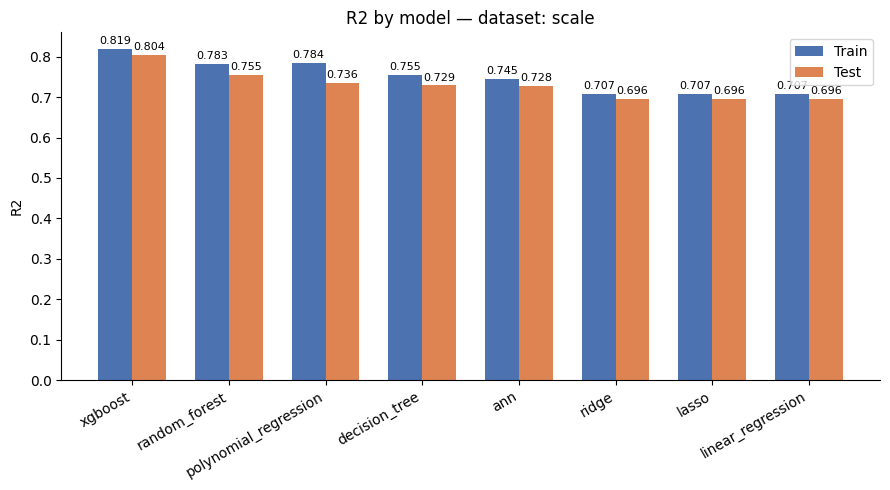

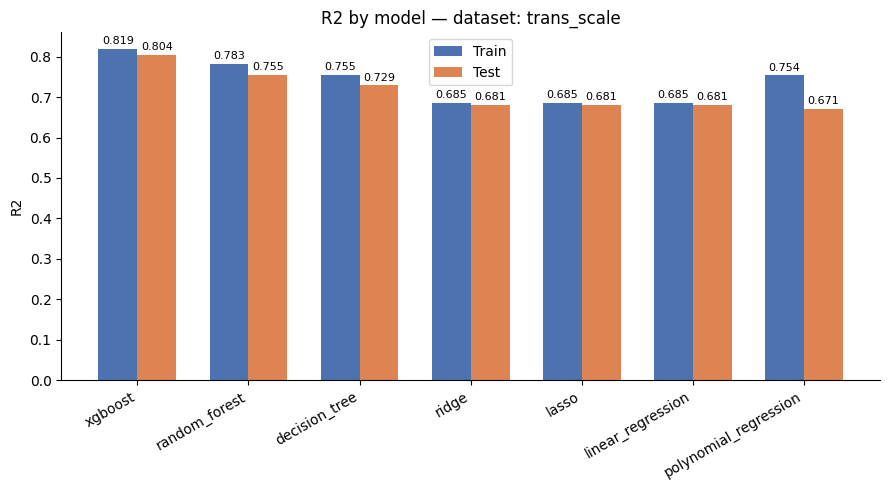

In [12]:
for dataset_name, group in results_df.groupby("dataset"):
    plot_grouped_bar(
        group,
        "train_R2",
        "test_R2",
        title=f"R2 by model — dataset: {dataset_name}",
        ylabel="R2",
    )

## Train time vs test time, per dataset

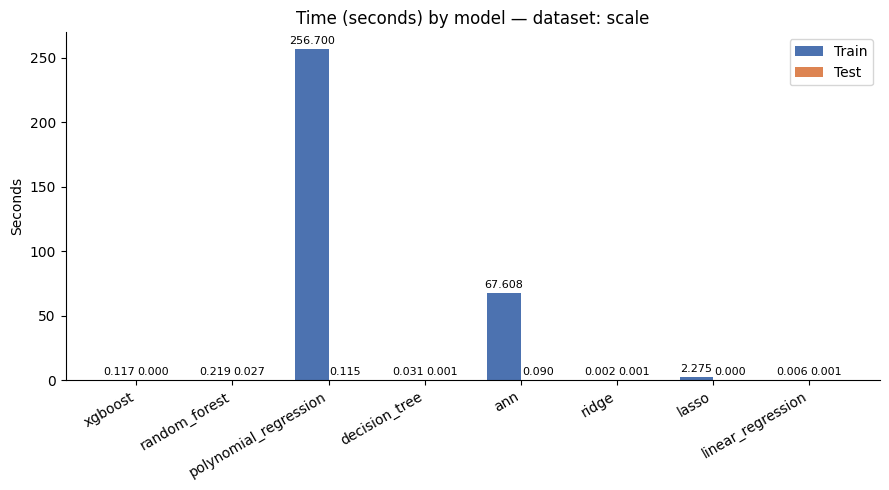

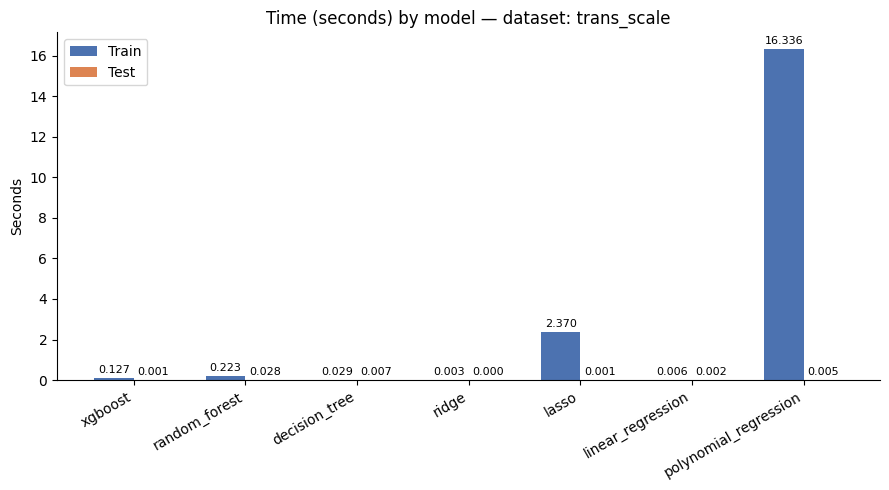

In [13]:
for dataset_name, group in results_df.groupby("dataset"):
    plot_grouped_bar(
        group,
        "train_time_sec",
        "test_time_sec",
        title=f"Time (seconds) by model — dataset: {dataset_name}",
        ylabel="Seconds",
        value_fmt="{:.3f}",
    )

## MAE: train vs test, per dataset

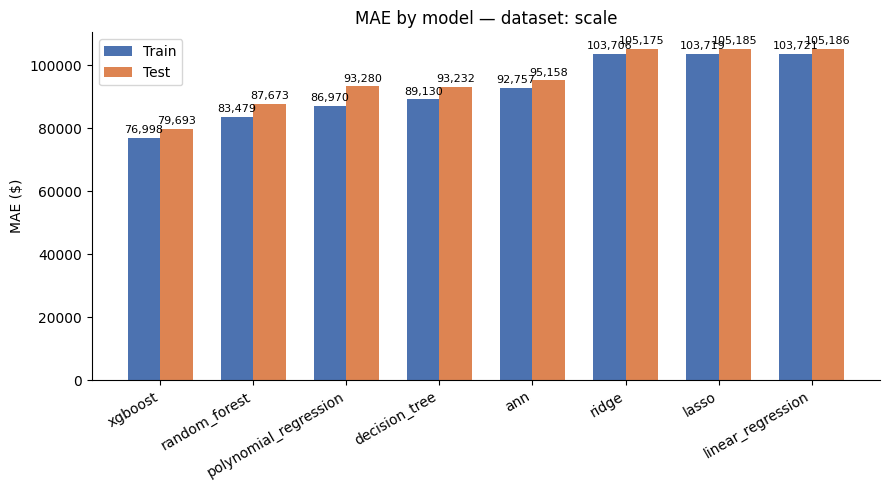

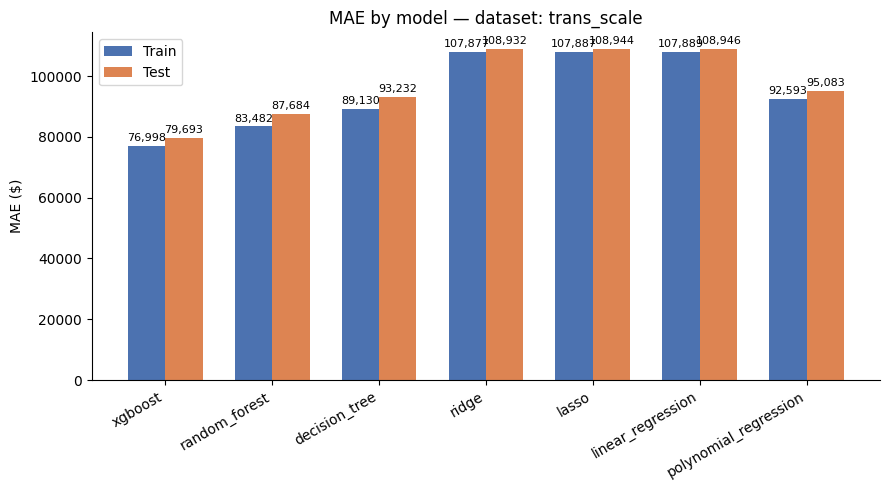

In [14]:
for dataset_name, group in results_df.groupby("dataset"):
    plot_grouped_bar(
        group,
        "train_MAE",
        "test_MAE",
        title=f"MAE by model — dataset: {dataset_name}",
        ylabel="MAE ($)",
        value_fmt="{:,.0f}",
    )

- As we can see clearly, best model we can use is XGBoosting, as it give us the highest results and very good inference time
- also transformation here not helped too much, so we can depend only on our standard scaled data